In [45]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from statsmodels.tsa.stattools import adfuller

# ── Core data handling ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# ── Seasonality & Decomposition ─────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── Stationarity Tests ──────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss

# ── Classical Forecasting Models ────────────────────────────────
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

# ── Facebook Prophet ────────────────────────────────────────────
from prophet import Prophet

# ── Machine Learning ────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ── Deep Learning ───────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

# ── Metrics ─────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_percentage_error  # MAPE
import math  # for math.sqrt(MSE) → RMSE

# ── Datetime utilities ──────────────────────────────────────────
from datetime import datetime, timedelta

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/rossmann-store-sales/sample_submission.csv
/kaggle/input/competitions/rossmann-store-sales/store.csv
/kaggle/input/competitions/rossmann-store-sales/train.csv
/kaggle/input/competitions/rossmann-store-sales/test.csv


In [4]:
import pandas as pd

# In Kaggle, datasets are always stored in the /kaggle/input/ directory
train = pd.read_csv('/kaggle/input/competitions/rossmann-store-sales/train.csv', parse_dates=['Date'])
store = pd.read_csv('/kaggle/input/competitions/rossmann-store-sales/store.csv')

store.head()

/tmp/ipykernel_55/3147696239.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('/kaggle/input/competitions/rossmann-store-sales/train.csv', parse_dates=['Date'])


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [6]:
# Merge and filter (just like we discussed)
df = pd.merge(train, store, on='Store', how='left')
df = df[df['Open'] == 1]
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# Look at the first 5 rows!
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
2,1,5,2013-01-04,4486,619,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,1,6,2013-01-05,4997,635,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
4,1,1,2013-01-07,7176,785,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN


In [7]:
#Check for nulls, duplicates , outliers 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[ns]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  object        
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  object        
 10  Assortment                 844392 non-null  object        
 11  CompetitionDistance        842206 non-null  float64 

In [8]:
# no duplicates

df.duplicated().sum()

np.int64(0)

In [9]:

df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2186
CompetitionOpenSinceMonth    268619
CompetitionOpenSinceYear     268619
Promo2                            0
Promo2SinceWeek              423307
Promo2SinceYear              423307
PromoInterval                423307
dtype: int64

In [10]:
#Observations

# CompetitionDistance            -> USING MEDIAN imputation for null values rather than mean because 5 rural stores will have 
                                    # large distance between competeting store than in urban areas

#

df_clean = df.copy()

In [11]:
# 1. Handle missing CompetitionDistance by replacing NaNs with the median value.
# Using .where() keeps the original value if the condition (~isna) is True, 
# and replaces it with 'other' (median_val) if False.
median_val = df_clean['CompetitionDistance'].median()
df_clean['CompetitionDistance'] = df_clean['CompetitionDistance'].where(~df_clean['CompetitionDistance'].isna(), other=median_val)

# 2. Fill missing time-based promotional and competition fields with 0.
# A value of 0 explicitly tells the algorithm the store is NOT participating or there is no competitor.
cols = ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear']
df_clean[cols] = df_clean[cols].fillna(0)

# 3. Fill missing PromoIntervals with the string '0' to prevent mixed-type errors later.
df_clean['PromoInterval'] = df_clean['PromoInterval'].fillna('0')

# 4. Prevent the "Mixed Data Type" trap by forcing StateHoliday (which contains 'a', 'b', 'c', and 0) to be a string.
df_clean['StateHoliday'] = df_clean['StateHoliday'].astype(str)

In [12]:
df_clean.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [13]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[ns]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  object        
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  object        
 10  Assortment                 844392 non-null  object        
 11  CompetitionDistance        844392 non-null  float64 

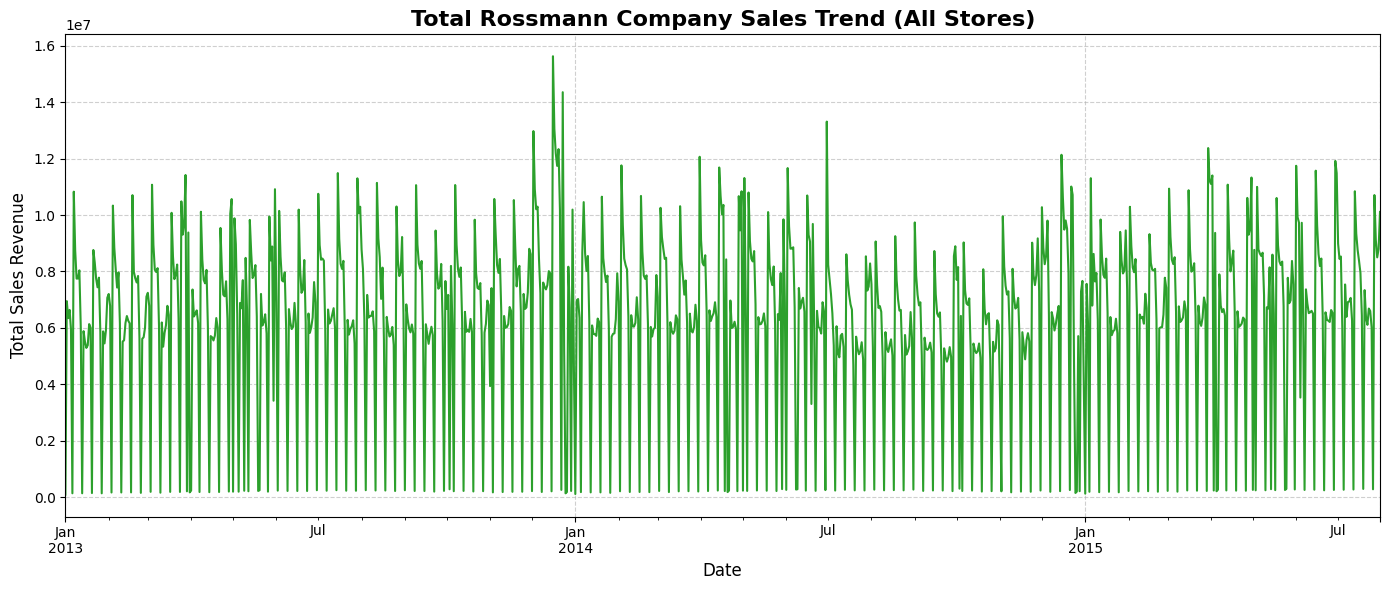

In [14]:
#Plotting time series plot - to gain insight on seasonality , trend and outliers

#df_clean.set_index('Date')['Sales'].plot(figsize = (10,5), title = 'Sales trend')



# 1. Aggregate the data: Group by Date and sum the sales across all stores
company_daily_sales = df_clean.groupby('Date')['Sales'].sum()

# 2. The Enhanced Plot
plt.figure(figsize=(14, 6)) # Slightly wider for better time scale visibility
company_daily_sales.plot(color='#2ca02c', linewidth=1.5) # Using a nice crisp green

# 3. Professional Formatting
plt.title('Total Rossmann Company Sales Trend (All Stores)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales Revenue', fontsize=12)

# Adding a grid makes it much easier to spot exact seasonal peaks
plt.grid(True, linestyle='--', alpha=0.6) 

# Clean up the layout
plt.tight_layout()
plt.show()

In [15]:
df_clean['Date'].describe()

count                           844392
mean     2014-04-11 01:02:42.487565312
min                2013-01-01 00:00:00
25%                2013-08-16 00:00:00
50%                2014-03-31 00:00:00
75%                2014-12-10 00:00:00
max                2015-07-31 00:00:00
Name: Date, dtype: object

In [16]:
#extracting the seasonality features from date

df_clean['Date'] = pd.to_datetime(df_clean['Date'])

df_clean['month'] = df_clean['Date'].dt.month

df_clean['day'] = df_clean['Date'].dt.day

df_clean['year'] = df_clean['Date'].dt.year

#df_clean['day_of_week'] = df_clean['Date'].dt.day_of_week
df_clean['day_name'] = df_clean['Date'].dt.day_name()

df_clean['is_weekend'] = df_clean['day_name'].isin(['Saturday','Sunday']).astype(int)

# Extract month start and end flags
df_clean['is_month_start'] = df_clean['Date'].dt.is_month_start.astype(int)
df_clean['is_month_end'] = df_clean['Date'].dt.is_month_end.astype(int)

df_clean['week_of_year'] = df_clean['Date'].dt.isocalendar().week

# Adding a 'Season' feature (Business Logic)
# 1: Winter, 2: Spring, 3: Summer, 4: Fall
df_clean['season'] = np.where(df_clean['month'].isin([12,1,2]), 1,
                     np.where(df_clean['month'].isin([3,4,5]), 2,
                     np.where(df_clean['month'].isin([6,7,8]), 3, 4)))

In [17]:
df_clean['SchoolHoliday'].value_counts()

SchoolHoliday
0    680935
1    163457
Name: count, dtype: int64

In [18]:
df_clean['is_state_holiday'] = (df_clean['StateHoliday'] != '0').astype(int)

In [19]:
df_clean.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,month,day,year,day_name,is_weekend,is_month_start,is_month_end,week_of_year,season,is_state_holiday
0,1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,1,2,2013,Wednesday,0,0,0,1,1,0
1,1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,1,3,2013,Thursday,0,0,0,1,1,0
2,1,5,2013-01-04,4486,619,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,1,4,2013,Friday,0,0,0,1,1,0
3,1,6,2013-01-05,4997,635,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,1,5,2013,Saturday,1,0,0,1,1,0
4,1,1,2013-01-07,7176,785,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,1,7,2013,Monday,0,0,0,2,1,0


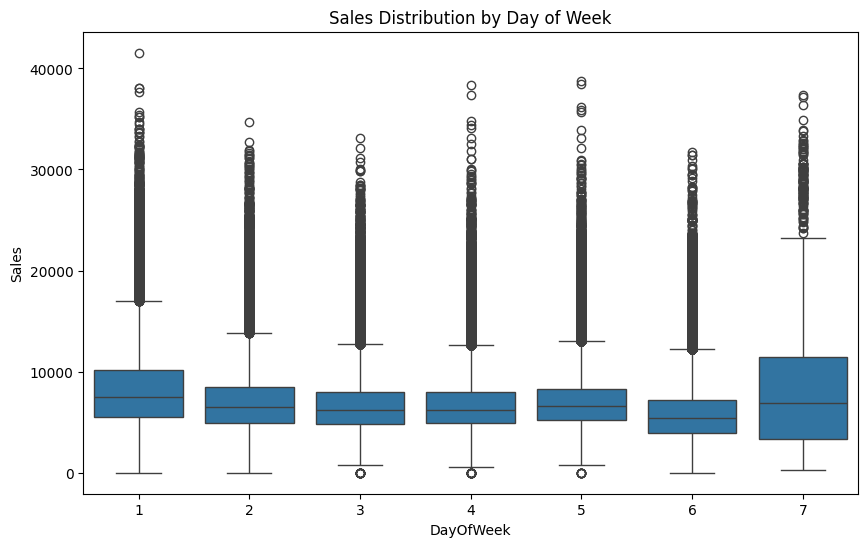

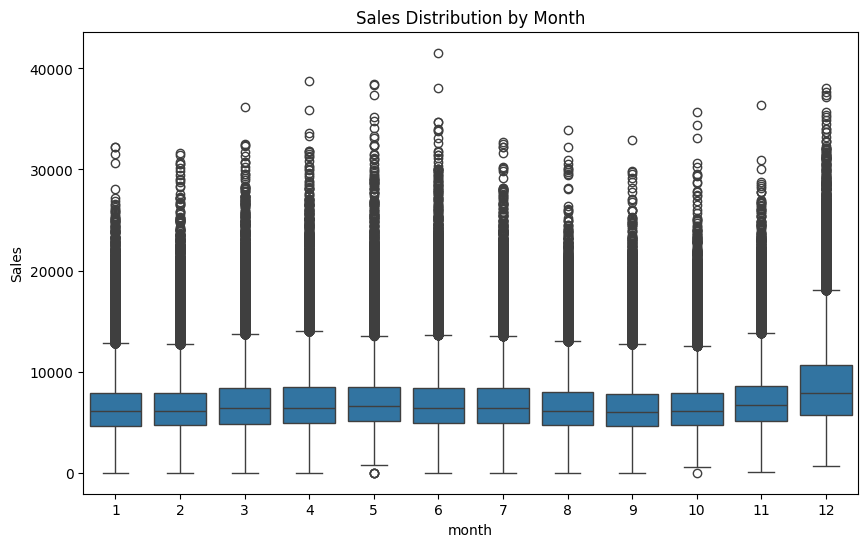

In [20]:
# 1. Boxplot by Day of Week - Does the day actually matter?
plt.figure(figsize=(10, 6))
sns.boxplot(x='DayOfWeek', y='Sales', data=df_clean)
plt.title('Sales Distribution by Day of Week')
plt.show()

# 2. Boxplot by Month - Identifying Yearly Seasonality
plt.figure(figsize=(10, 6))
sns.boxplot(x='month', y='Sales', data=df_clean)
plt.title('Sales Distribution by Month')
plt.show()

#In retail forecasting, "outliers" are rarely errors; they are usually extreme business events.

In [21]:
#Stationary test

# We use the daily total sales we calculated for the plot
company_daily_sales = df_clean.groupby('Date')['Sales'].sum()

result = adfuller(company_daily_sales)

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]:.4f}')

#Data is stationary , since p_value < 0.05 -> we reject null hypothesis

'''
I initially checked stationarity at the aggregated level, which gives a high-level understanding of overall trends.

However, since the modeling is done at the store level, each store represents an independent time series.
In practice, testing stationarity for each store is computationally expensive and unnecessary for tree-based models
like XGBoost, which do not assume stationarity.

Therefore, I focused on capturing temporal patterns using lag and rolling features instead.
'''

ADF Statistic: -4.761614524595615
p-value: 0.0001


'\nI initially checked stationarity at the aggregated level, which gives a high-level understanding of overall trends.\n\nHowever, since the modeling is done at the store level, each store represents an independent time series.\nIn practice, testing stationarity for each store is computationally expensive and unnecessary for tree-based models\nlike XGBoost, which do not assume stationarity.\n\nTherefore, I focused on capturing temporal patterns using lag and rolling features instead.\n'

In [22]:
df_clean.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'month', 'day', 'year', 'day_name',
       'is_weekend', 'is_month_start', 'is_month_end', 'week_of_year',
       'season', 'is_state_holiday'],
      dtype='object')

In [23]:
df_clean['Store'].value_counts()

Store
1097    942
85      942
335     942
562     942
682     942
       ... 
909     607
100     606
744     605
348     597
644     592
Name: count, Length: 1115, dtype: int64

In [24]:
df_clean_copy = df_clean.copy()

In [25]:
'''
The Golden Rule of Time-Series Engineering:

Sort by Time and Entity (Store).

Create "Past-Looking" features (Lags, Rolling Means of the past).

Drop the Burn-in NaNs.

Then execute the Time-Based Split.

'''

'\nThe Golden Rule of Time-Series Engineering:\n\nSort by Time and Entity (Store).\n\nCreate "Past-Looking" features (Lags, Rolling Means of the past).\n\nDrop the Burn-in NaNs.\n\nThen execute the Time-Based Split.\n\n'

In [26]:
df_clean_copy.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,month,day,year,day_name,is_weekend,is_month_start,is_month_end,week_of_year,season,is_state_holiday
0,1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,1,2,2013,Wednesday,0,0,0,1,1,0
1,1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,1,3,2013,Thursday,0,0,0,1,1,0
2,1,5,2013-01-04,4486,619,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,1,4,2013,Friday,0,0,0,1,1,0
3,1,6,2013-01-05,4997,635,1,0,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,1,5,2013,Saturday,1,0,0,1,1,0
4,1,1,2013-01-07,7176,785,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,1,7,2013,Monday,0,0,0,2,1,0


In [27]:
#Adding lagging and leading parameters

def feature_eng_lead_lag(df_clean_copy):

    df_clean_copy['lag1'] = df_clean_copy.groupby('Store')['Sales'].shift(1)

    df_clean_copy['lag7'] = df_clean_copy.groupby('Store')['Sales'].shift(7)

    df_clean_copy['lag14'] = df_clean_copy.groupby('Store')['Sales'].shift(14)

    df_clean_copy['lag30'] = df_clean_copy.groupby('Store')['Sales'].shift(30)

    df_clean_copy['rolling_mean_7days'] = df_clean_copy.groupby('Store')['Sales'].transform(
    lambda x: x.shift(1).rolling(window=7).mean() )

    # Lag_1: Was there a promo yesterday?
    df_clean_copy['promo_lag_1'] = df_clean_copy.groupby('Store')['Promo'].shift(1)

    #Is there a promo tomorrow?
    df_clean_copy['promo_lead_1'] = df_clean_copy.groupby('Store')['Promo'].shift(-1)

    # --- 3. The Burn-In Drop ---
    # We must drop NaNs caused by both our forward (lead) and backward (lag) shifts
    df_clean_copy = df_clean_copy.dropna(subset = ['lag1','lag7','lag14','lag30','rolling_mean_7days','promo_lag_1','promo_lead_1'])

    return df_clean_copy

In [28]:
df_features_eng = feature_eng_lead_lag(df_clean_copy)

df_features_eng.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,month,day,year,day_name,is_weekend,is_month_start,is_month_end,week_of_year,season,is_state_holiday,lag1,lag7,lag14,lag30,rolling_mean_7days,promo_lag_1,promo_lead_1
30,1,3,2013-02-06,6140,693,1,1,0,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2,6,2013,Wednesday,0,0,0,6,1,0,6049.0,3725.0,5394.0,5530.0,5388.428571,1.0,1.0
31,1,4,2013-02-07,5499,675,1,1,0,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2,7,2013,Thursday,0,0,0,6,1,0,6140.0,4601.0,5720.0,4327.0,5733.428571,1.0,1.0
32,1,5,2013-02-08,5681,630,1,1,0,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2,8,2013,Friday,0,0,0,6,1,0,5499.0,4709.0,5578.0,4486.0,5861.714286,1.0,0.0
33,1,6,2013-02-09,5370,656,1,0,0,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2,9,2013,Saturday,1,0,0,6,1,0,5681.0,5633.0,5195.0,4997.0,6000.571429,1.0,0.0
34,1,1,2013-02-11,4409,599,1,0,0,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2,11,2013,Monday,0,0,0,7,1,0,5370.0,5970.0,5586.0,7176.0,5963.000000,0.0,0.0


In [29]:
df_features_eng.info()

<class 'pandas.core.frame.DataFrame'>
Index: 809827 entries, 30 to 844390
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      809827 non-null  int64         
 1   DayOfWeek                  809827 non-null  int64         
 2   Date                       809827 non-null  datetime64[ns]
 3   Sales                      809827 non-null  int64         
 4   Customers                  809827 non-null  int64         
 5   Open                       809827 non-null  int64         
 6   Promo                      809827 non-null  int64         
 7   StateHoliday               809827 non-null  object        
 8   SchoolHoliday              809827 non-null  int64         
 9   StoreType                  809827 non-null  object        
 10  Assortment                 809827 non-null  object        
 11  CompetitionDistance        809827 non-null  float64     

In [30]:
df_features_eng.isna().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
month                        0
day                          0
year                         0
day_name                     0
is_weekend                   0
is_month_start               0
is_month_end                 0
week_of_year                 0
season                       0
is_state_holiday             0
lag1                         0
lag7                         0
lag14                        0
lag30                        0
rolling_

In [31]:
df_features_eng.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'month', 'day', 'year', 'day_name',
       'is_weekend', 'is_month_start', 'is_month_end', 'week_of_year',
       'season', 'is_state_holiday', 'lag1', 'lag7', 'lag14', 'lag30',
       'rolling_mean_7days', 'promo_lag_1', 'promo_lead_1'],
      dtype='object')

In [32]:
# splitting and training data

print(pd.to_datetime(df_features_eng['Date'].max()))

2015-07-30 00:00:00


In [33]:
latest_date = pd.to_datetime(df_features_eng['Date'].max())

cutoff_date = latest_date - pd.Timedelta(days=30)

print(latest_date)
print(cutoff_date)
#print(df_features_eng[latest_date])

2015-07-30 00:00:00
2015-06-30 00:00:00


In [34]:
df_features_eng.info()

<class 'pandas.core.frame.DataFrame'>
Index: 809827 entries, 30 to 844390
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      809827 non-null  int64         
 1   DayOfWeek                  809827 non-null  int64         
 2   Date                       809827 non-null  datetime64[ns]
 3   Sales                      809827 non-null  int64         
 4   Customers                  809827 non-null  int64         
 5   Open                       809827 non-null  int64         
 6   Promo                      809827 non-null  int64         
 7   StateHoliday               809827 non-null  object        
 8   SchoolHoliday              809827 non-null  int64         
 9   StoreType                  809827 non-null  object        
 10  Assortment                 809827 non-null  object        
 11  CompetitionDistance        809827 non-null  float64     

In [35]:
df_features_eng.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,month,day,year,day_name,is_weekend,is_month_start,is_month_end,week_of_year,season,is_state_holiday,lag1,lag7,lag14,lag30,rolling_mean_7days,promo_lag_1,promo_lead_1
30,1,3,2013-02-06,6140,693,1,1,0,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2,6,2013,Wednesday,0,0,0,6,1,0,6049.0,3725.0,5394.0,5530.0,5388.428571,1.0,1.0
31,1,4,2013-02-07,5499,675,1,1,0,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2,7,2013,Thursday,0,0,0,6,1,0,6140.0,4601.0,5720.0,4327.0,5733.428571,1.0,1.0
32,1,5,2013-02-08,5681,630,1,1,0,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2,8,2013,Friday,0,0,0,6,1,0,5499.0,4709.0,5578.0,4486.0,5861.714286,1.0,0.0
33,1,6,2013-02-09,5370,656,1,0,0,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2,9,2013,Saturday,1,0,0,6,1,0,5681.0,5633.0,5195.0,4997.0,6000.571429,1.0,0.0
34,1,1,2013-02-11,4409,599,1,0,0,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2,11,2013,Monday,0,0,0,7,1,0,5370.0,5970.0,5586.0,7176.0,5963.000000,0.0,0.0


In [36]:

df_train = df_features_eng[df_features_eng['Date'] < cutoff_date]
df_test = df_features_eng[df_features_eng['Date'] >= cutoff_date]

In [37]:
# Define the exact columns to drop from our Features (X).
# CRITICAL: We KEEP 'StoreType' and 'Assortment' so the Pipeline can encode them!
columns_to_drop = [
    'Sales',           # Target variable (moves to y)
    'Customers',       # Future leakage trap
    'Date',            # Datetime (crashes XGBoost)
    'StateHoliday',    # Original string (we use our engineered 'is_state_holiday' flag instead)
    'PromoInterval',   # String (crashes XGBoost)
    'day_name'         # String (crashes XGBoost)
]

# Create Training sets
X_train = df_train.drop(columns=columns_to_drop, errors='ignore')
y_train = df_train['Sales']

# Create Testing sets
X_test = df_test.drop(columns=columns_to_drop, errors='ignore')
y_test = df_test['Sales']

# ==========================================
# STEP 2: BUILD THE PREPROCESSOR
# ==========================================
# Tell the transformer which columns need One-Hot Encoding
categorical_cols = ['StoreType', 'Assortment']

# Create the transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    # 'passthrough' tells it to leave our numeric columns (lags, rolling means) completely alone
    remainder='passthrough' 
)

# ==========================================
# STEP 3: ASSEMBLE THE PIPELINE
# ==========================================
# Connect the preprocessor directly to the XGBoost algorithm
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,        # Number of trees to build
        learning_rate=0.05,      # Speed of learning
        max_depth=6,             # Maximum depth of each tree
        random_state=42,         # Ensures reproducible results
        n_jobs=-1                # Uses all available CPU cores
    ))
])

# ==========================================
# STEP 4: TRAIN THE MODEL
# ==========================================

pipeline.fit(X_train, y_train)
print("Training Complete!\n")

# ==========================================
# STEP 5: PREDICT & EVALUATE
# ==========================================
print("Generating predictions for the 30-day test set...")
predictions = pipeline.predict(X_test)

# Calculate Accuracy Metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

# MAPE calculation: We add 1 to y_test to prevent dividing by zero on days stores are closed
mape = np.mean(np.abs((y_test - predictions) / (y_test + 1))) * 100

print("-" * 30)
print("MODEL PERFORMANCE METRICS")
print("-" * 30)
print(f"MAE:  €{mae:.2f}")
print(f"RMSE: €{rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

Training Complete!

Generating predictions for the 30-day test set...
------------------------------
MODEL PERFORMANCE METRICS
------------------------------
MAE:  €686.82
RMSE: €945.29
MAPE: 10.38%


In [38]:
# 1. Define the Parameter Grid
# WARNING: Keep this small for your first run! Every option multiplies the training time.
# 2 rates * 2 depths * 2 estimators = 8 combinations.
param_grid = {
    'model__learning_rate': [0.01, 0.05],
    'model__max_depth': [6, 8],
    'model__n_estimators': [500, 800]
}

# 2. Set up the Time-Series Safe Cross-Validation
# This tests the model chronologically (e.g., Train Jan-Mar -> Test Apr, then Train Jan-Apr -> Test May)
tscv = TimeSeriesSplit(n_splits=3)

# 3. Build the GridSearchCV Object
print("Initializing Grid Search...")
grid_search = GridSearchCV(
    estimator=pipeline,           # The pipeline we built in the last step!
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error', # Optimize to reduce huge misses
    cv=tscv,                      # The time-series safe splitter
    n_jobs=-1,                    # Use all CPU cores
    verbose=2                     # Print progress so you don't think it froze
)

# 4. Run the Search! (Go grab a coffee, this will take a few minutes)
print("Starting the brutal hyperparameter battle...")
grid_search.fit(X_train, y_train)

# 5. The Reveal
print("\n" + "="*40)
print("GRID SEARCH COMPLETE")
print("="*40)
print(f"Best Parameters Found: {grid_search.best_params_}")

# 6. Extract the Ultimate Champion Model
best_pipeline = grid_search.best_estimator_

Initializing Grid Search...
Starting the brutal hyperparameter battle...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

GRID SEARCH COMPLETE
Best Parameters Found: {'model__learning_rate': 0.01, 'model__max_depth': 8, 'model__n_estimators': 800}


In [39]:
#best_pipeline.fit(X_train, y_train)
#print("best parameter Training Complete!\n")

# ==========================================
# STEP 5: PREDICT & EVALUATE
# ==========================================
print("Generating predictions for the 30-day test set...")
best_predictions = best_pipeline.predict(X_test)

# Calculate Accuracy Metrics
mae = mean_absolute_error(y_test, best_predictions)
rmse = np.sqrt(mean_squared_error(y_test, best_predictions))

# MAPE calculation: We add 1 to y_test to prevent dividing by zero on days stores are closed
mape = np.mean(np.abs((y_test - best_predictions) / (y_test + 1))) * 100

print("-" * 30)
print("Optimised MODEL PERFORMANCE METRICS")
print("-" * 30)
print(f"MAE:  €{mae:.2f}")
print(f"RMSE: €{rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

Generating predictions for the 30-day test set...
------------------------------
Optimised MODEL PERFORMANCE METRICS
------------------------------
MAE:  €649.91
RMSE: €912.59
MAPE: 9.76%


In [40]:
scores = best_pipeline.named_steps['model'].feature_importances_

print(scores)

[0.01387784 0.00540379 0.00455709 0.00368707 0.0054959  0.00724554
 0.0032312  0.00404709 0.03965876 0.         0.19989732 0.00617174
 0.00513304 0.00344535 0.00383719 0.00406358 0.00500081 0.00540209
 0.00751308 0.01246198 0.00602903 0.         0.         0.00931296
 0.01295786 0.00529625 0.00464459 0.39814404 0.00392851 0.01586818
 0.01161519 0.09317099 0.09085292 0.00804901]


In [44]:
import pandas as pd

# 1. Extract the preprocessor and the model from your winning pipeline
preprocessor = best_pipeline.named_steps['preprocessor']
xgb_model = best_pipeline.named_steps['model']

# 2. Get the feature names and clean off the ugly Scikit-Learn prefixes
clean_names = [name.split('__')[-1] for name in preprocessor.get_feature_names_out()]

# 3. Get the mathematical importance scores (Information Gain)
scores = xgb_model.feature_importances_

# 4. Build a simple table, sort it, and grab the Top 15
top_15_df = pd.DataFrame({
    'Feature': clean_names,
    'Importance Score': scores
}).sort_values(by='Importance Score', ascending=False).head(10)

# 5. Print the clean table without the row numbers
print("-" * 40)
print("TOP 10 DRIVERS OF ROSSMANN SALES")
print("-" * 40)
print(top_15_df.to_string(index=False))

----------------------------------------
TOP 10 DRIVERS OF ROSSMANN SALES
----------------------------------------
           Feature  Importance Score
              lag1          0.398144
             Promo          0.199897
rolling_mean_7days          0.093171
       promo_lag_1          0.090853
         DayOfWeek          0.039659
             lag14          0.015868
       StoreType_a          0.013878
      week_of_year          0.012958
               day          0.012462
             lag30          0.011615


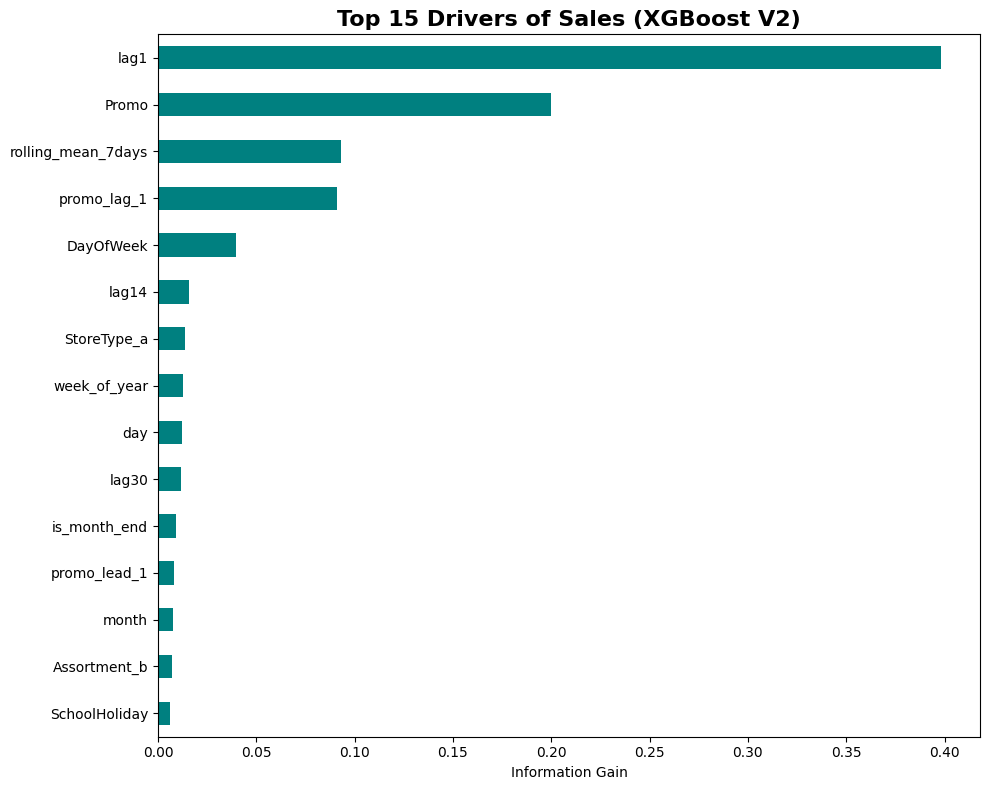

In [46]:
plt.figure(figsize=(10, 8))
importance_df.tail(15).plot(kind='barh', x='Feature', y='Importance', color='teal', legend=False, ax=plt.gca())
plt.title('Top 15 Drivers of Sales (XGBoost V2)', fontsize=16, fontweight='bold')
plt.xlabel('Information Gain')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [48]:
print("Running Error Analysis Autopsy...")
# Grab the original test data so we have the Date and Customer context
error_df = df_test[['Store', 'Date', 'Sales', 'Customers', 'Promo', 'is_state_holiday', 'DayOfWeek']].copy()

# Add our optimized predictions (rounded to the nearest Euro)
error_df['Predicted_Sales'] = best_predictions.round(0)

# Calculate the Absolute Error
error_df['Error_Euros'] = abs(error_df['Sales'] - error_df['Predicted_Sales'])

# Sort the dataframe to find the Top 10 biggest misses
worst_predictions = error_df.sort_values(by='Error_Euros', ascending=False).head(10)

print("-" * 75)
print("THE WALL OF SHAME: TOP 10 WORST PREDICTIONS")
print("-" * 75)
print(worst_predictions.to_string(index=False))
print("\n")

Running Error Analysis Autopsy...
---------------------------------------------------------------------------
THE WALL OF SHAME: TOP 10 WORST PREDICTIONS
---------------------------------------------------------------------------
 Store       Date  Sales  Customers  Promo  is_state_holiday  DayOfWeek  Predicted_Sales  Error_Euros
   876 2015-07-06  27330       1653      0                 0          1           9436.0      17894.0
   909 2015-07-20  23081       1767      0                 0          1          10024.0      13057.0
   876 2015-07-04  14708        598      0                 0          6           3329.0      11379.0
   876 2015-07-07  23927       1687      0                 0          2          13137.0      10790.0
   909 2015-07-18  16051       1347      0                 0          6           7588.0       8463.0
   842 2015-07-08  21883       1231      0                 0          3          14448.0       7435.0
   368 2015-07-27  18878       1061      1              

In [49]:
#SERIALIZATION (SAVING THE BRAIN)
# ==========================================
print("Saving the V2 Pipeline to disk...")

# Save the model as a .pkl file
file_name = 'rossmann_xgboost_v2.pkl'
joblib.dump(best_pipeline, file_name)

print(f"SUCCESS! Model safely saved as '{file_name}'.")
print("Project Complete. Ready for deployment.")

Saving the V2 Pipeline to disk...
SUCCESS! Model safely saved as 'rossmann_xgboost_v2.pkl'.
Project Complete. Ready for deployment.
